1. Создание сети

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds, LinearConstraint
from scipy.optimize import linprog

np.random.seed(42)
N = 8  # количество узлов (>=5)

# Параметры узлов
V = np.random.randint(50, 500, size=N)           # ценность узла
C = np.random.randint(10, 100, size=N)           # стоимость защиты
P_succ_def = np.random.uniform(0.05, 0.3, size=N)     # вероятность успеха атаки при защите
P_succ_no_def = np.random.uniform(0.7, 0.95, size=N)  # вероятность успеха атаки без защиты

# Бюджет защитника (40% от стоимости защиты всех узлов)
B = 0.4 * np.sum(C)

print("=" * 70)
print("Модель безопасности сети (игра Штакельберга)")
print("=" * 70)
print(f"Количество узлов: {N}")
print(f"Бюджет защитника: {B:.2f} (30% от полной защиты)\n")
print("Узел | Ценность V | Стоимость C | P(успех при защите) | P(успех без защиты)")
print("-" * 75)
for i in range(N):
    print(f"{i+1:4d} | {V[i]:9d} | {C[i]:10d} | {P_succ_def[i]:18.3f} | {P_succ_no_def[i]:19.3f}")

Модель безопасности сети (игра Штакельберга)
Количество узлов: 8
Бюджет защитника: 211.60 (30% от полной защиты)

Узел | Ценность V | Стоимость C | P(успех при защите) | P(успех без защиты)
---------------------------------------------------------------------------
   1 |       152 |         92 |              0.064 |               0.706
   2 |       485 |         96 |              0.230 |               0.831
   3 |       398 |         84 |              0.285 |               0.800
   4 |       320 |         84 |              0.050 |               0.712
   5 |       156 |         97 |              0.298 |               0.943
   6 |       121 |         33 |              0.204 |               0.758
   7 |       238 |         12 |              0.203 |               0.723
   8 |        70 |         31 |              0.052 |               0.855


2. Функции полезности

In [18]:
def expected_damage(x, i):
    # Ожидаемый ущерб при атаке на узел i
    # x[i] - вероятность защиты узла i

    return V[i] * (x[i] * P_succ_def[i] + (1 - x[i]) * P_succ_no_def[i])

def all_expected_damages(x):
    # Ожидаемый ущерб для всех узлов

    return np.array([expected_damage(x, i) for i in range(N)])

def attacker_response(x):
    # Атакующий выбирает узел, максимизирующий ожидаемый ущерб
    # Возвращает: (индекс выбранного узла, максимальный ущерб)

    damages = all_expected_damages(x)
    max_damage = np.max(damages)
    targets = np.where(np.abs(damages - max_damage) < 1e-6)[0]
    return targets[0], max_damage

def defender_objective(x):
    # Цель защитника: минимизировать максимальный ожидаемый ущерб
    # с учётом рациональной реакции атакующего
    
    x_clipped = np.clip(x, 0, 1)
    _, max_damage = attacker_response(x_clipped)
    return max_damage


3. Поиск равновесия Штакельберга

In [19]:
# Бюджетное ограничение: sum(x_i * C_i) <= B
# Ограничения: 0 <= x_i <= 1

# Начальное приближение: равномерное распределение
x0 = np.ones(N) * (B / np.sum(C))
x0 = np.clip(x0, 0, 1)

# Оптимизация
result = minimize(
    defender_objective,
    x0,
    method='SLSQP',
    bounds=[(0, 1) for _ in range(N)],
    constraints={'type': 'ineq', 'fun': lambda x: B - np.sum(x * C)},
    options={'maxiter': 2000, 'disp': True}
)

if result.success:
    x_opt = np.clip(result.x, 0, 1)
    print("\n" + "=" * 70)
    print("Равновесие Штакельберга найдено")
    print("=" * 70)
else:
    print("\nПредупреждение: оптимизация не сошлась, используется начальное приближение")
    x_opt = x0

Optimization terminated successfully    (Exit mode 0)
            Current function value: 136.89760908326866
            Iterations: 26
            Function evaluations: 295
            Gradient evaluations: 26

Равновесие Штакельберга найдено


4. Анализ полученных результатов

In [20]:
damages = all_expected_damages(x_opt)
target_idx, max_damage = attacker_response(x_opt)
total_cost = np.sum(x_opt * C)

print("\n--- Стратегия защитника (смешанная защита) ---")
print("Узел | Вероятность защиты x_i | Затраты C_i * x_i")
print("-" * 55)
for i in range(N):
    print(f"{i+1:4d} | {x_opt[i]:20.4f} | {C[i] * x_opt[i]:12.2f}")
print("-" * 55)
print(f"Итого затраты: {total_cost:.2f} (бюджет: {B:.2f})")

print("\n--- Ожидаемый ущерб при атаке на каждый узел ---")
for i in range(N):
    marker = " <- ВЫБРАН АТАКУЮЩИМ" if i == target_idx else ""
    print(f"Узел {i+1}: {damages[i]:.3f}{marker}")

print("\n--- Результат игры Штакельберга ---")
print(f"Атакующий выбирает узел {target_idx + 1}")
print(f"Максимальный ожидаемый ущерб (цель защитника): {max_damage:.3f}")


--- Стратегия защитника (смешанная защита) ---
Узел | Вероятность защиты x_i | Затраты C_i * x_i
-------------------------------------------------------
   1 |               0.0000 |         0.00
   2 |               0.9147 |        87.81
   3 |               0.8849 |        74.33
   4 |               0.4303 |        36.15
   5 |               0.1021 |         9.90
   6 |               0.0000 |         0.00
   7 |               0.2837 |         3.40
   8 |               0.0000 |         0.00
-------------------------------------------------------
Итого затраты: 211.60 (бюджет: 211.60)

--- Ожидаемый ущерб при атаке на каждый узел ---
Узел 1: 107.276
Узел 2: 136.637
Узел 3: 136.897
Узел 4: 136.642
Узел 5: 136.898 <- ВЫБРАН АТАКУЮЩИМ
Узел 6: 91.741
Узел 7: 136.897
Узел 8: 59.822

--- Результат игры Штакельберга ---
Атакующий выбирает узел 5
Максимальный ожидаемый ущерб (цель защитника): 136.898


5. Визуализация

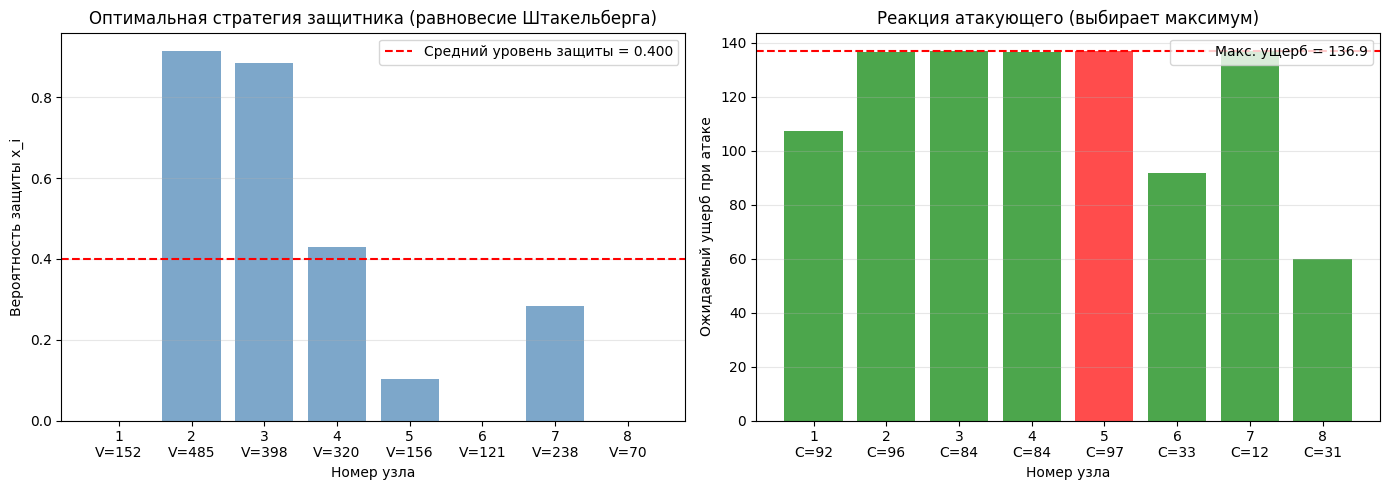

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Стратегия защиты
ax1.bar(range(1, N+1), x_opt, color='steelblue', alpha=0.7)
ax1.axhline(y=B/np.sum(C), color='red', linestyle='--', 
            label=f'Средний уровень защиты = {B/np.sum(C):.3f}')
ax1.set_xlabel('Номер узла')
ax1.set_ylabel('Вероятность защиты x_i')
ax1.set_title('Оптимальная стратегия защитника (равновесие Штакельберга)')
ax1.set_xticks(range(1, N+1))
ax1.set_xticklabels([f'{i}\nV={V[i-1]}' for i in range(1, N+1)])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# График 2: Ожидаемый ущерб
colors = ['green' if i != target_idx else 'red' for i in range(N)]
ax2.bar(range(1, N+1), damages, color=colors, alpha=0.7)
ax2.axhline(y=max_damage, color='red', linestyle='--', label=f'Макс. ущерб = {max_damage:.1f}')
ax2.set_xlabel('Номер узла')
ax2.set_ylabel('Ожидаемый ущерб при атаке')
ax2.set_title('Реакция атакующего (выбирает максимум)')
ax2.set_xticks(range(1, N+1))
ax2.set_xticklabels([f'{i}\nC={C[i-1]}' for i in range(1, N+1)])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()